Tratamento e Visualização dos Dados - Raman
===

**Autor:** [Mateus de Jesus Mendes](mailto:mateus25032@ilum.cnpem.br)

##### **Funções**

Importação de bibliotecas:

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid

Leitura e normalização dos dados:

In [230]:
def scaling(file_path, method='max'):
    """
    Lê e normaliza dados de espectroscopia Raman.

    ### Parâmetros
    - file_path (str): Caminho do arquivo contendo duas colunas (Raman shift e intensidade).
    - method (str):

        Método de normalização:
            - 'max'   : Divide pela intensidade máxima (padrão)
            - 'area'  : Divide pela área total (normalização integral)
            - 'zscore': Centraliza e escala (média 0, desvio padrão 1)

    ### Retorna
    Tupla contendo o número de ondas e as intensidades normalizadas.
    """

    # Leitura dos dados
    try:
        data = np.loadtxt(file_path)
    except Exception as e:
        raise ValueError(f'Erro ao ler o arquivo {file_path}: {e}')

    if data.shape[1] < 2:
        raise ValueError('O arquivo deve conter pelo menos duas colunas (x e y).')

    x = data[:, 0]
    y = data[:, 1].astype(float)

    # Normalização
    if method == 'max':
        y_norm = y / np.max(y)
    elif method == 'area':
        area = np.trapezoid(y, x)
        y_norm = y / area
    elif method == 'zscore':
        y_norm = (y - np.mean(y)) / np.std(y)
    else:
        raise ValueError('Método inválido. Use: "max", "area" ou "zscore".')

    return x, y_norm

Plot singular:

In [231]:
def raman_plot(file_path, sample_name=None, method='max'):
    """
    Gera plots (Matplotlib e Plotly) de um único espectro Raman.

    ### Parâmetros
    - file_path (str): Caminho do arquivo contendo dados de espectroscopia Raman.
    - sample_name (object): Nome da amostra.
    - method (str):

        Método de normalização:
            - 'max'   : Divide pela intensidade máxima (padrão)
            - 'area'  : Divide pela área total (normalização integral)
            - 'zscore': Centraliza e escala (média 0, desvio padrão 1)
    """

    X, Y = scaling(file_path, method=method)    

    # Matplotlib
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    plt.plot(X, Y, linewidth=1)
    plt.xlabel('Número de Ondas (cm⁻¹)')
    plt.ylabel('Intensidade (u.a.)')
    plt.title(f'Espectro Raman — {sample_name}')
    plt.show()

    # Plotly
    fig_raman = go.Figure()

    fig_raman.add_trace(go.Scatter(
        x=X,
        y=Y,
        mode='lines',
        line=dict(width=1),
        name='Raman'
    ))

    fig_raman.update_layout(
        title=f'Espectro Raman — {sample_name}',
        xaxis=dict(title='Número de Ondas (cm⁻¹)'),
        yaxis=dict(title='Intensidade (u.a.)'),
        template='simple_white',
        width=800,
        height=500
    )

    fig_raman.show()

Plot conjunto (*overlayed*):

In [232]:
def raman_overlay(file_paths, sample_names=None, method='max'):
    """
    Gera plots (Matplotlib e Plotly) de múltiplos espectros Raman em overlay.

    ### Parâmetros

    - file_paths (list of str): Lista de caminhos dos arquivos contendo dados de espectroscopia Raman.
    - sample_names (list of str, optional): Nomes das amostras.
    - method (str):
    
        Método de normalização:
            - 'max'   : Divide pela intensidade máxima (padrão)
            - 'area'  : Divide pela área total (normalização integral)
            - 'zscore': Centraliza e escala (média 0, desvio padrão 1)
    """

    # Matplotlib
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    
    for file_path, sample_name in zip(file_paths, sample_names):
            X, Y = scaling(file_path, method=method)

            plt.plot(X, Y, linewidth=1, label=sample_name)

    plt.xlabel('Número de Ondas (cm⁻¹)')
    plt.ylabel('Intensidade (u.a.)')
    plt.title('Sobreposição de Espectros Raman')
    plt.legend()
    plt.show()

    # Plotly
    fig_raman = go.Figure()

    for fp, label in zip(file_paths, sample_names):
        data_raman = []
        with open(fp, 'r') as f:
            for line in f:
                if line.startswith('##') or line.strip() == '':
                    continue
                parts = line.strip().split()
                if len(parts) >= 2:
                    try:
                        x, y = map(float, parts[:2])
                        data_raman.append((x, y))
                    except:
                        continue

        df_raman = pd.DataFrame(data_raman, columns=['Wavenumber', 'Intensity'])
        fig_raman.add_trace(go.Scatter(
            x=df_raman['Wavenumber'],
            y=df_raman['Intensity'],
            mode='lines',
            line=dict(width=1),
            name=label
        ))

    fig_raman.update_layout(
        title='Sobreposição de Espectros Raman',
        xaxis=dict(title='Número de Ondas (cm⁻¹)'),
        yaxis=dict(title='Intensidade (u.a.)'),
        template='simple_white',
        width=800,
        height=500
    )

    fig_raman.show()

Cálculo do *baseline*:

In [233]:
def als(file_path, lam=1e5, p=0.01, n_iter=10, method='max'):
    """
    Correção baseline via Mínimos Quadrados Assimétricos (Assymetric Least Squares - ALS).

    ### Parâmetros
    - file_path (str): Caminho do arquivo contendo dados de espectroscopia Raman.
    - lam (float) : Parâmetro de homogeneidade
    - p (float) : Parâmetro de assimetria (p ~ 0.001-0.1 para Raman)
    - n_iter (int) : Número de iterações

    ### Retorna
    Tupla contendo a correção baseline dos dados.
    """

    x, y = scaling(file_path=file_path, method=method)
  
    L = len(y)
    # Second-difference Matrix
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L))
    D = D.T @ D
    w = np.ones(L)
    for i in range(n_iter):
        W = sparse.diags(w, 0)
        Z = W + lam * D
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y <= z)

    return x, y, z

Aplicação integrada entre cálculo do *baseline* e visualização gráfica:

In [234]:
def baseline(file_path, lam=1e6, p=0.01, n_iter=10):
    """
    ### Parâmetros
    - file_path (str): Caminho do arquivo contendo dados de espectroscopia Raman.
    - lam (float) : Parâmetro de homogeneidade
    - p (float) : Parâmetro de assimetria (p ~ 0.001-0.1 for Raman)
    - n_iter (int) : Número de iterações

    ### Retorna
    Tupla contendo o número de ondas e a correção baseline dos dados de intensidade.
    """

    x, y, bsl = als(file_path=file_path, lam=lam, p=p, n_iter=n_iter)

    y_smooth = savgol_filter(y, window_length=11, polyorder=3)
    y_corr = y_smooth - bsl     # y_corr = y_baseline_subtraído

    # Matplotlib
    plt.figure(figsize=(6.3, 4.2), dpi=300)
    plt.plot(x, y, label='Dado bruto', alpha=0.6)
    plt.plot(x, bsl, label='Baseline', linewidth=2)
    plt.plot(x, y_corr, label='Corrigido', linewidth=1)
    plt.title('Correção dos Dados de Espectroscopia Raman por Baseline - GO')
    plt.legend()
    plt.xlabel('Número de Ondas  (cm⁻¹)')
    plt.ylabel('Intensidade (u.a.)')
    plt.tight_layout()
    plt.show()

    # Plotly
    fig = go.Figure()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='lines',
        name='Dado bruto',
        opacity=0.6,
        line=dict(color='#1f77b4')
    ))

    fig.add_trace(go.Scatter(
        x=x, y=bsl,
        mode='lines',
        name='Baseline',
        line=dict(color='#ff7f0e', width=2)
    ))

    fig.add_trace(go.Scatter(
        x=x, y=y_corr,
        mode='lines',
        name='Corrigido',
        line=dict(color='#2ca02c', width=1)
    ))

    fig.update_layout(
        title='Correção dos Dados de Espectroscopia Raman por Baseline - GO',
        xaxis_title='Número de Ondas  (cm⁻¹)',
        yaxis_title='Intensidade (u.a.)',
        template='plotly_white',
        width=800,
        height=400,
        legend=dict(
            title='',
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        )
    )

    fig.show()

    return x, y_corr

# Raman - GO

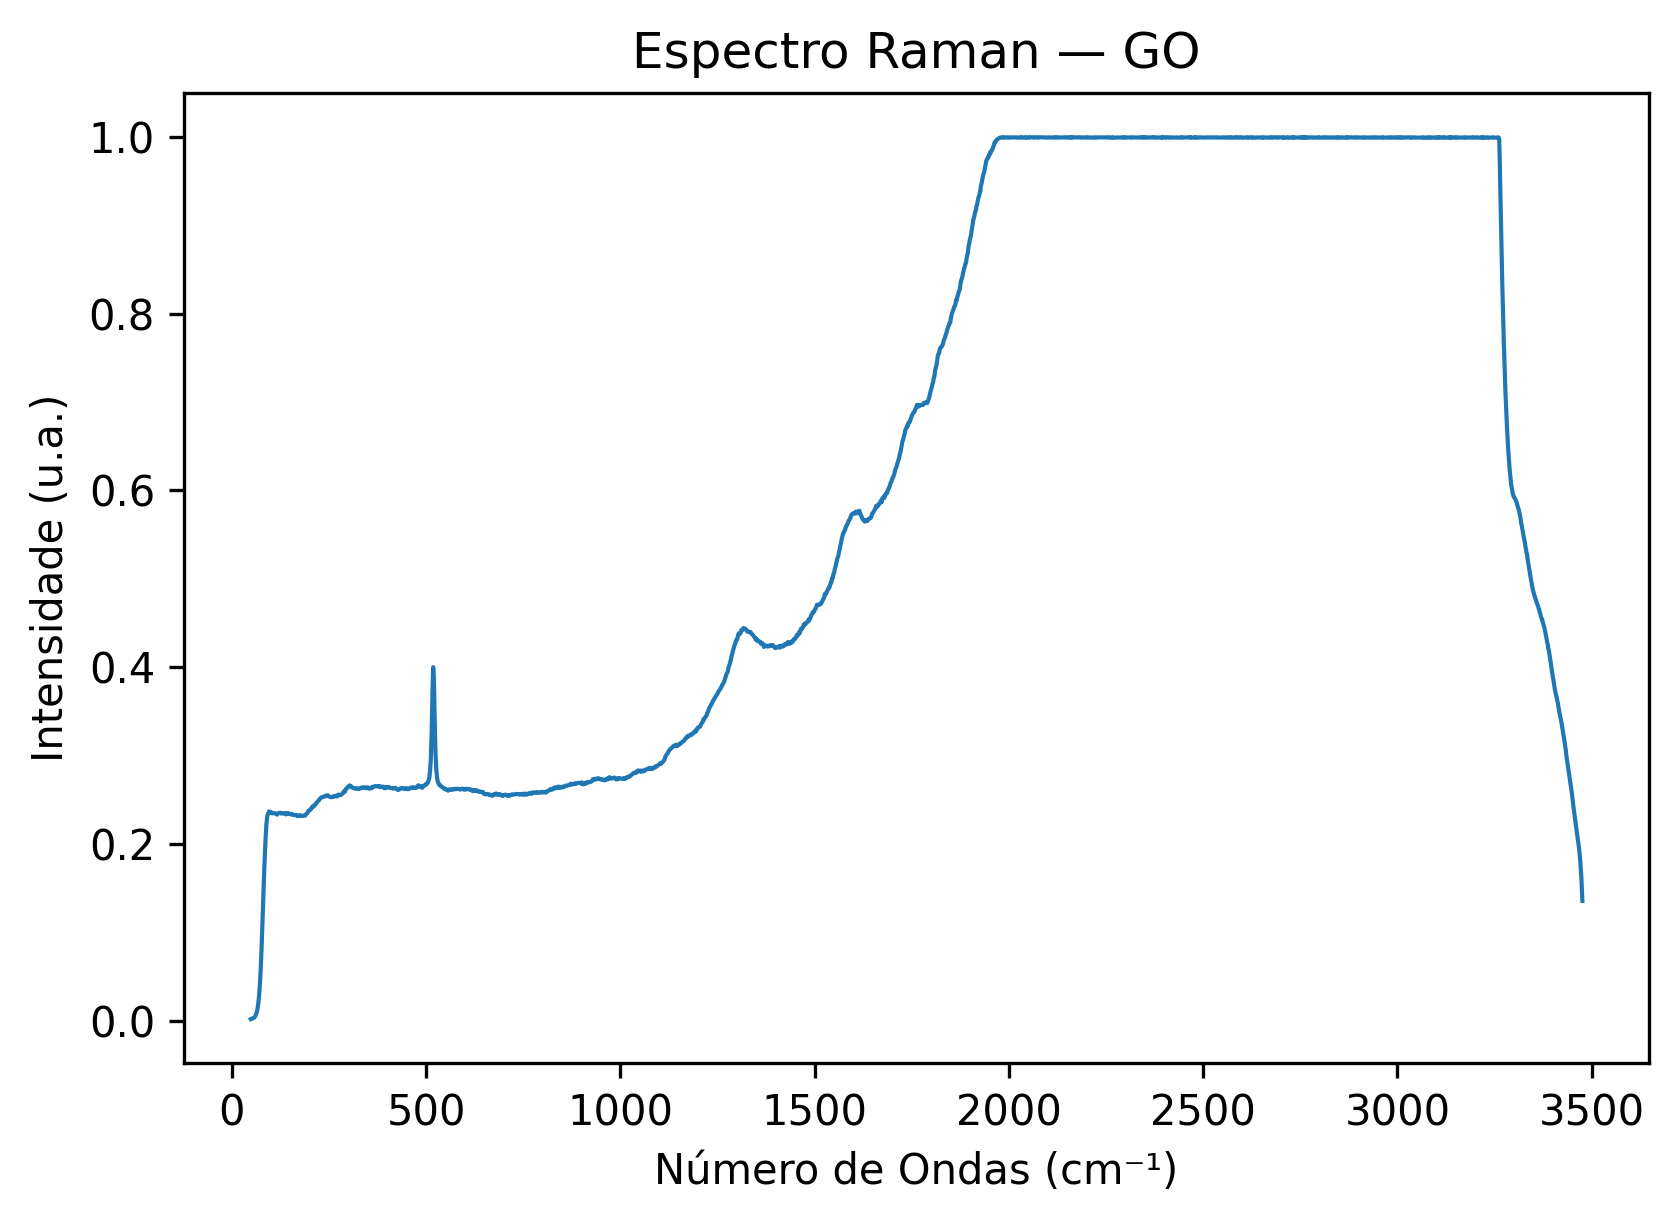

In [235]:
raman_plot(file_path='GO_MMV.txt', sample_name='GO', method='max')

# Raman - rGO

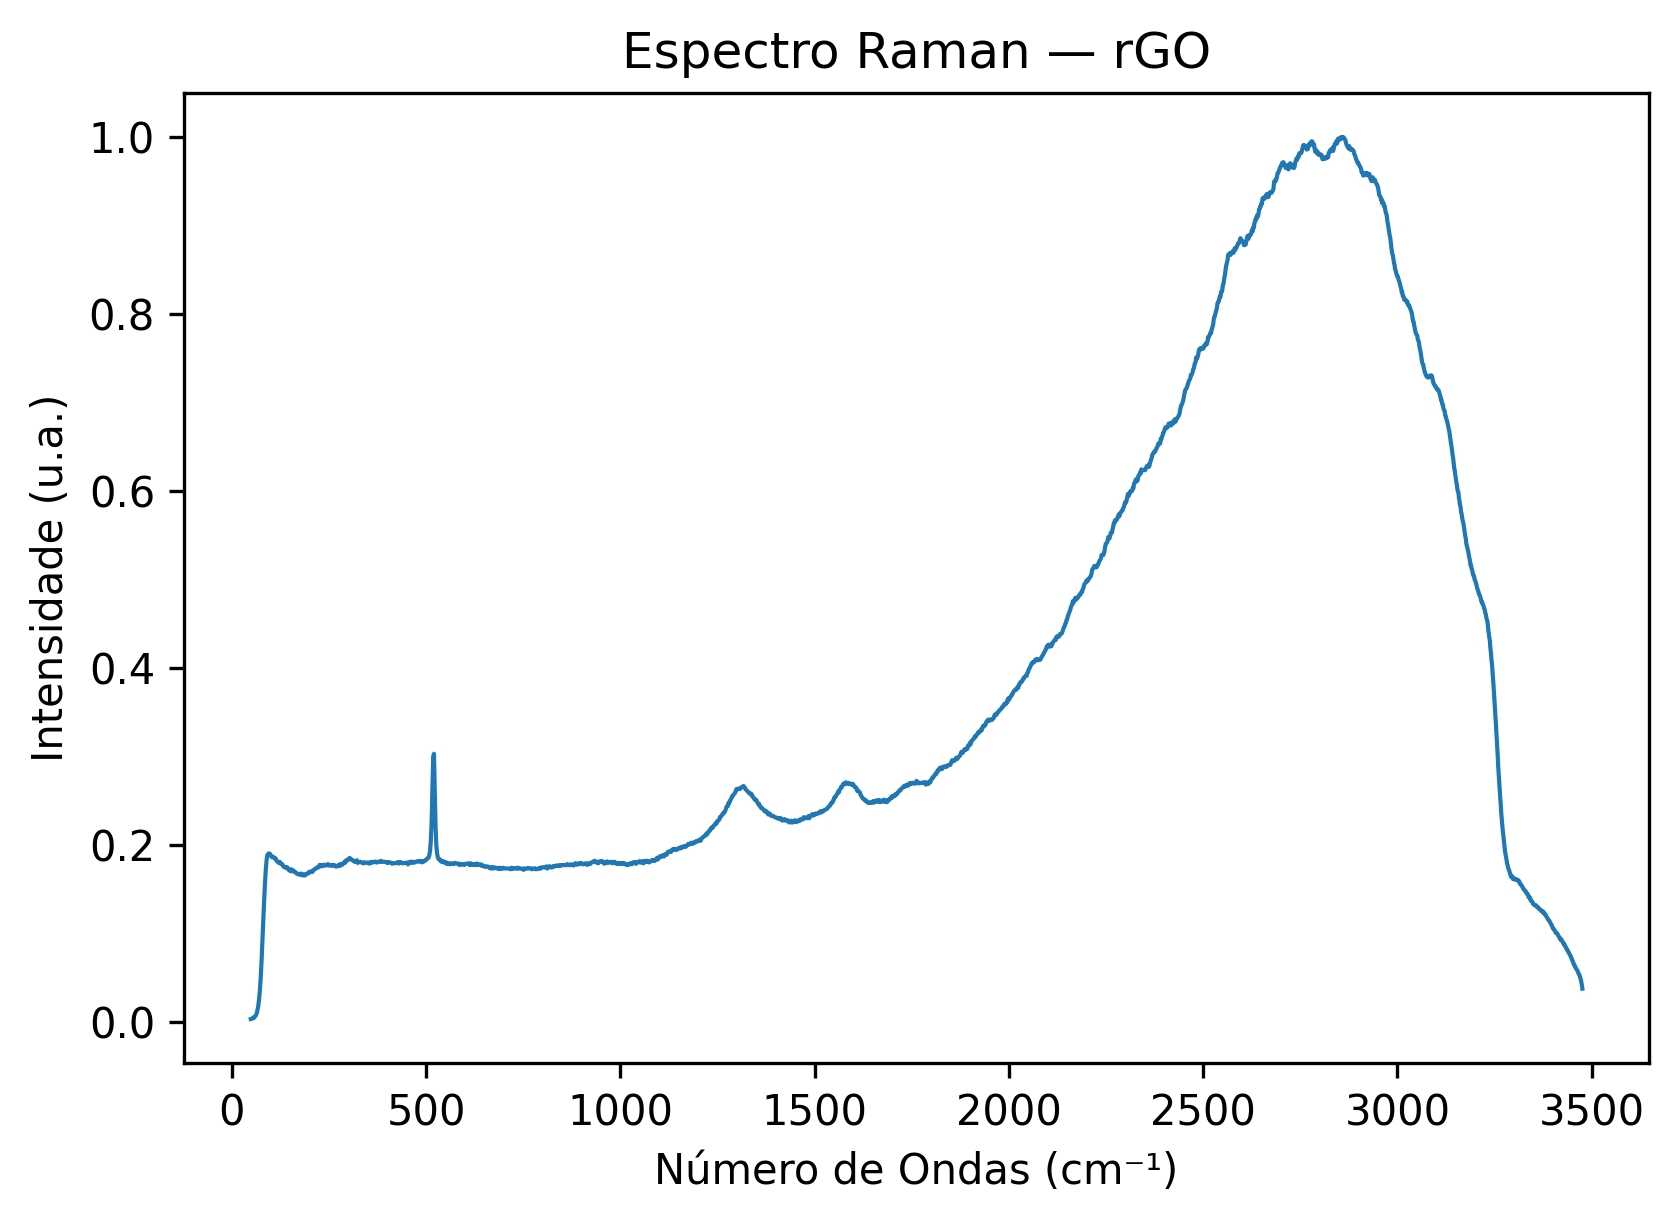

In [236]:
raman_plot(file_path='rGO_MMV.txt', sample_name='rGO', method='max')

# *Overlay*

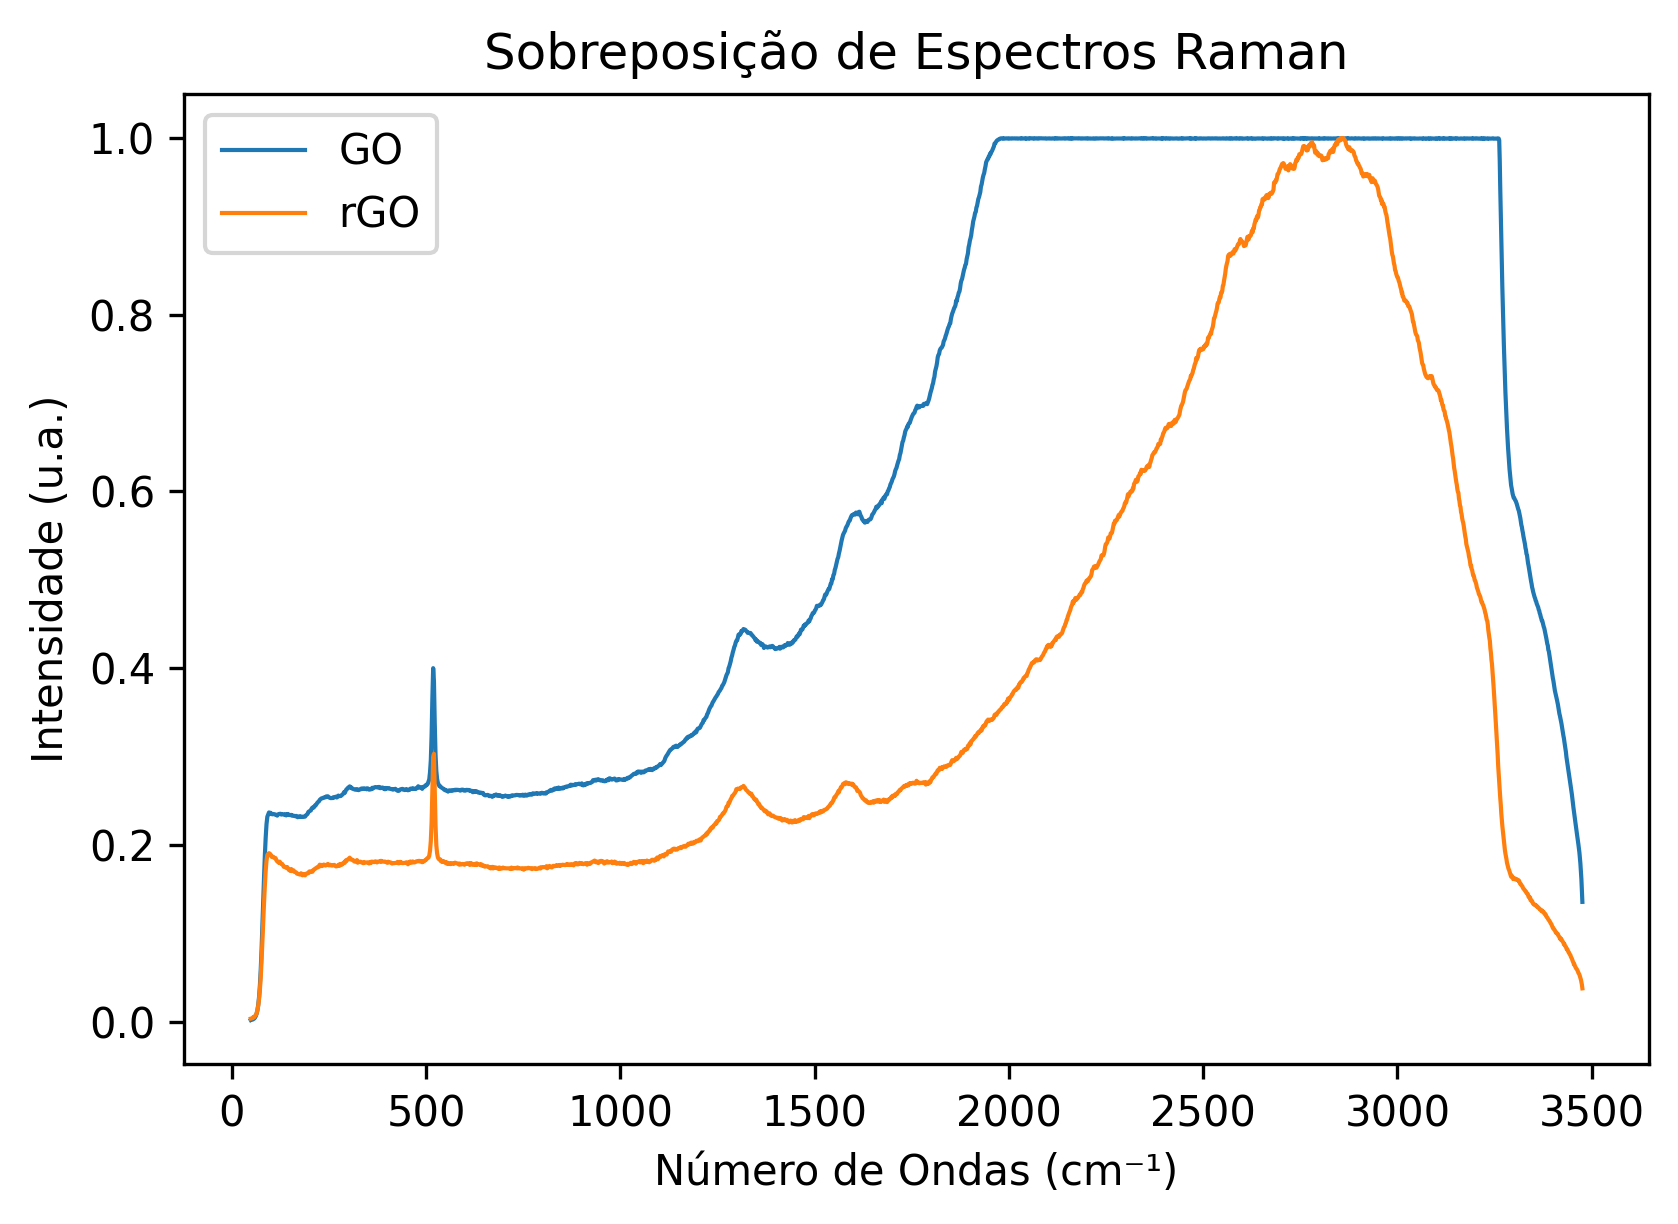

In [237]:
raman_overlay(file_paths=('GO_MMV.txt', 'rGO_MMV.txt'), sample_names=('GO', 'rGO'))

# *Baseline* - GO

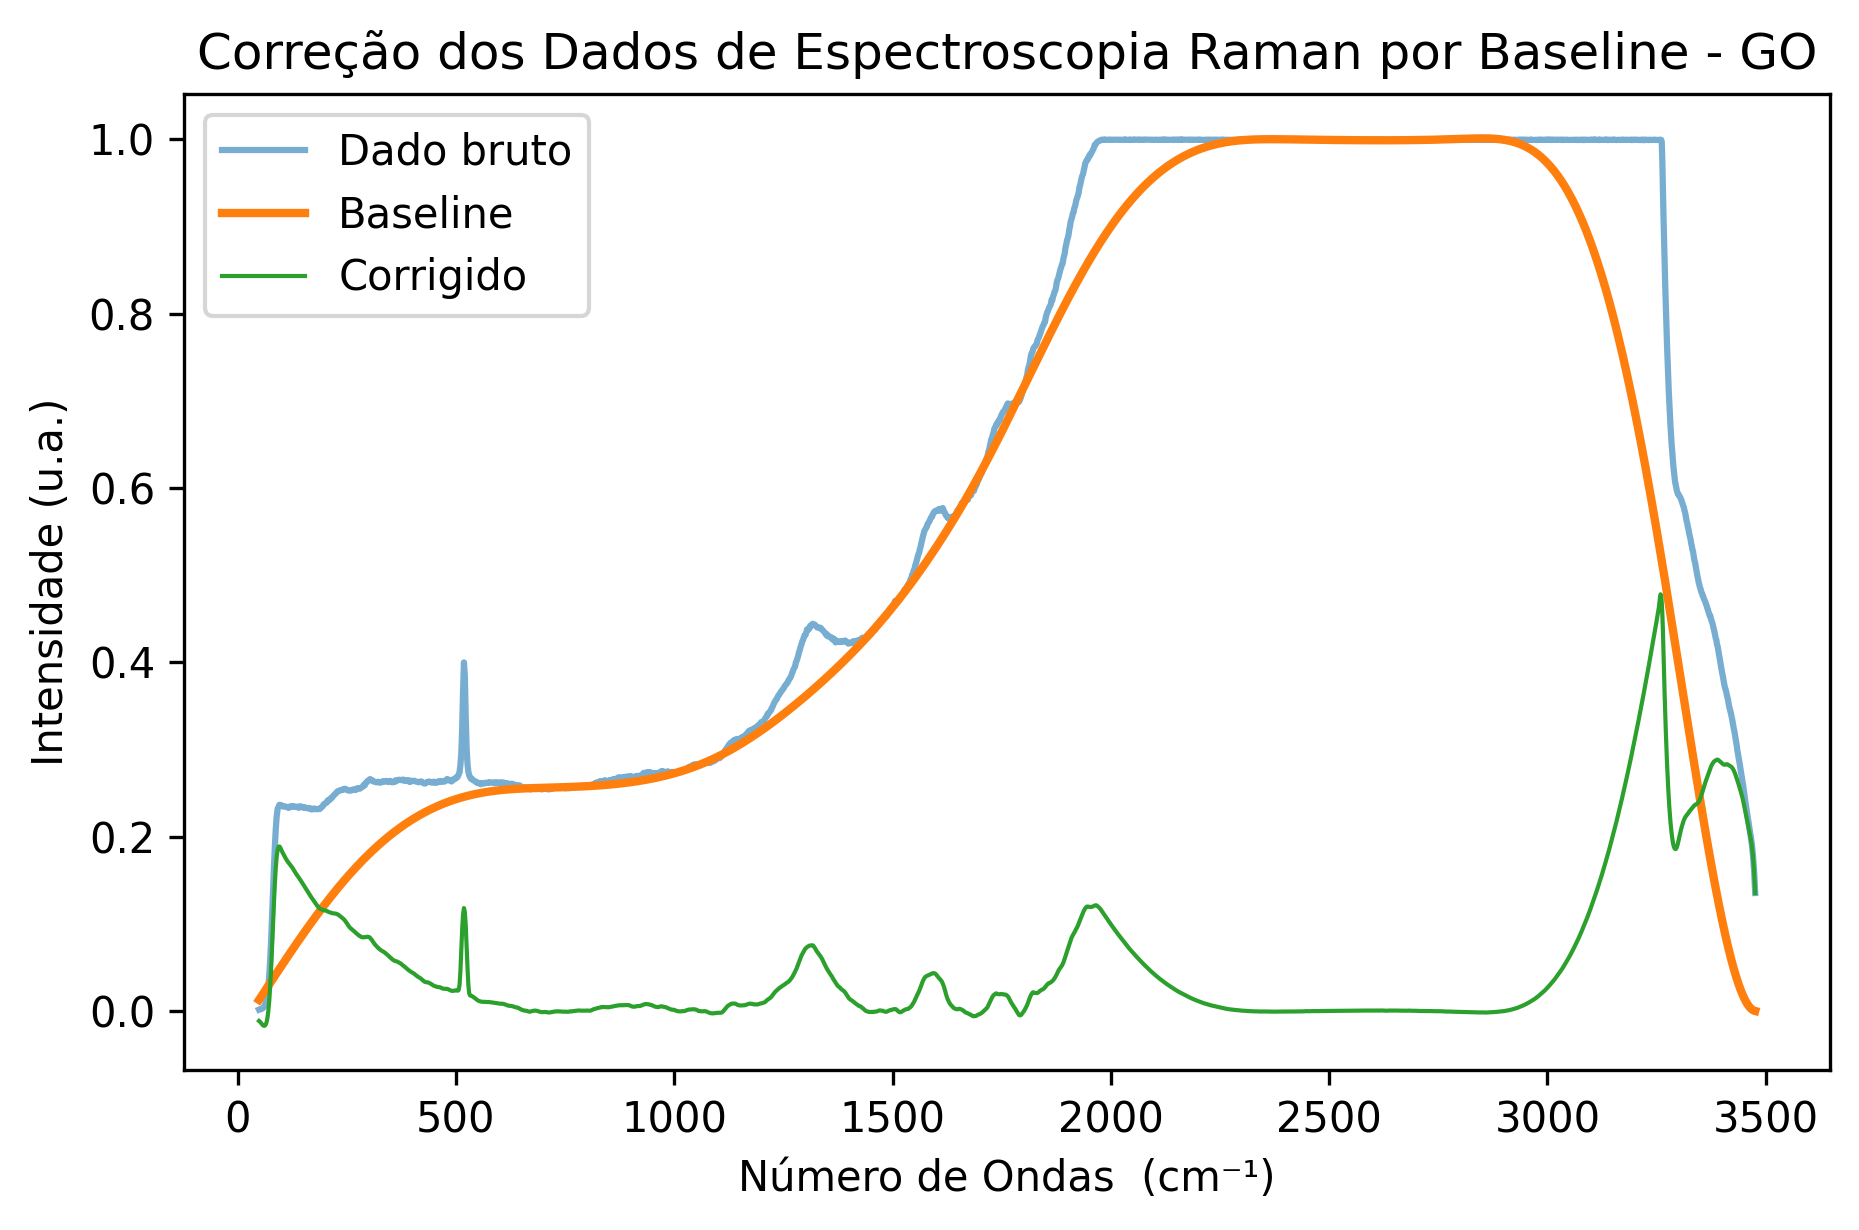

In [238]:
x, y_corr = baseline('GO_MMV.txt', lam=1e6, p=0.01, n_iter=10)

Área sob o pico D:

In [239]:
xmin, xmax = 1115.56, 1439.89 # Limites definidos para o pico D
mask = (x >= xmin) & (x <= xmax)
area_D_GO = -trapezoid(y_corr[mask], x[mask])
print(f'Área sob o pico D (GO): {area_D_GO} (u.a.)')

Área sob o pico D (GO): 9.022787802354946 (u.a.)


Área sob o pico G:

In [240]:
xmin, xmax = 1525.43, 1660.53 # Limites definidos para o pico G
mask = (x >= xmin) & (x <= xmax)
area_G_GO = -trapezoid(y_corr[mask], x[mask])    # y_corr = y_baseline_subtraído
print(f'Área sob o pico G (GO): {area_G_GO} (u.a.)')

Área sob o pico G (GO): 2.7582135699233588 (u.a.)


Razão entre as áreas ($\mathrm{\frac{A_D}{A_G}}$):

In [241]:
DG_ratio = area_D_GO / area_G_GO
print(f'Razão D/G (GO): {DG_ratio}')

Razão D/G (GO): 3.2712433514006887


# *Baseline* - rGO

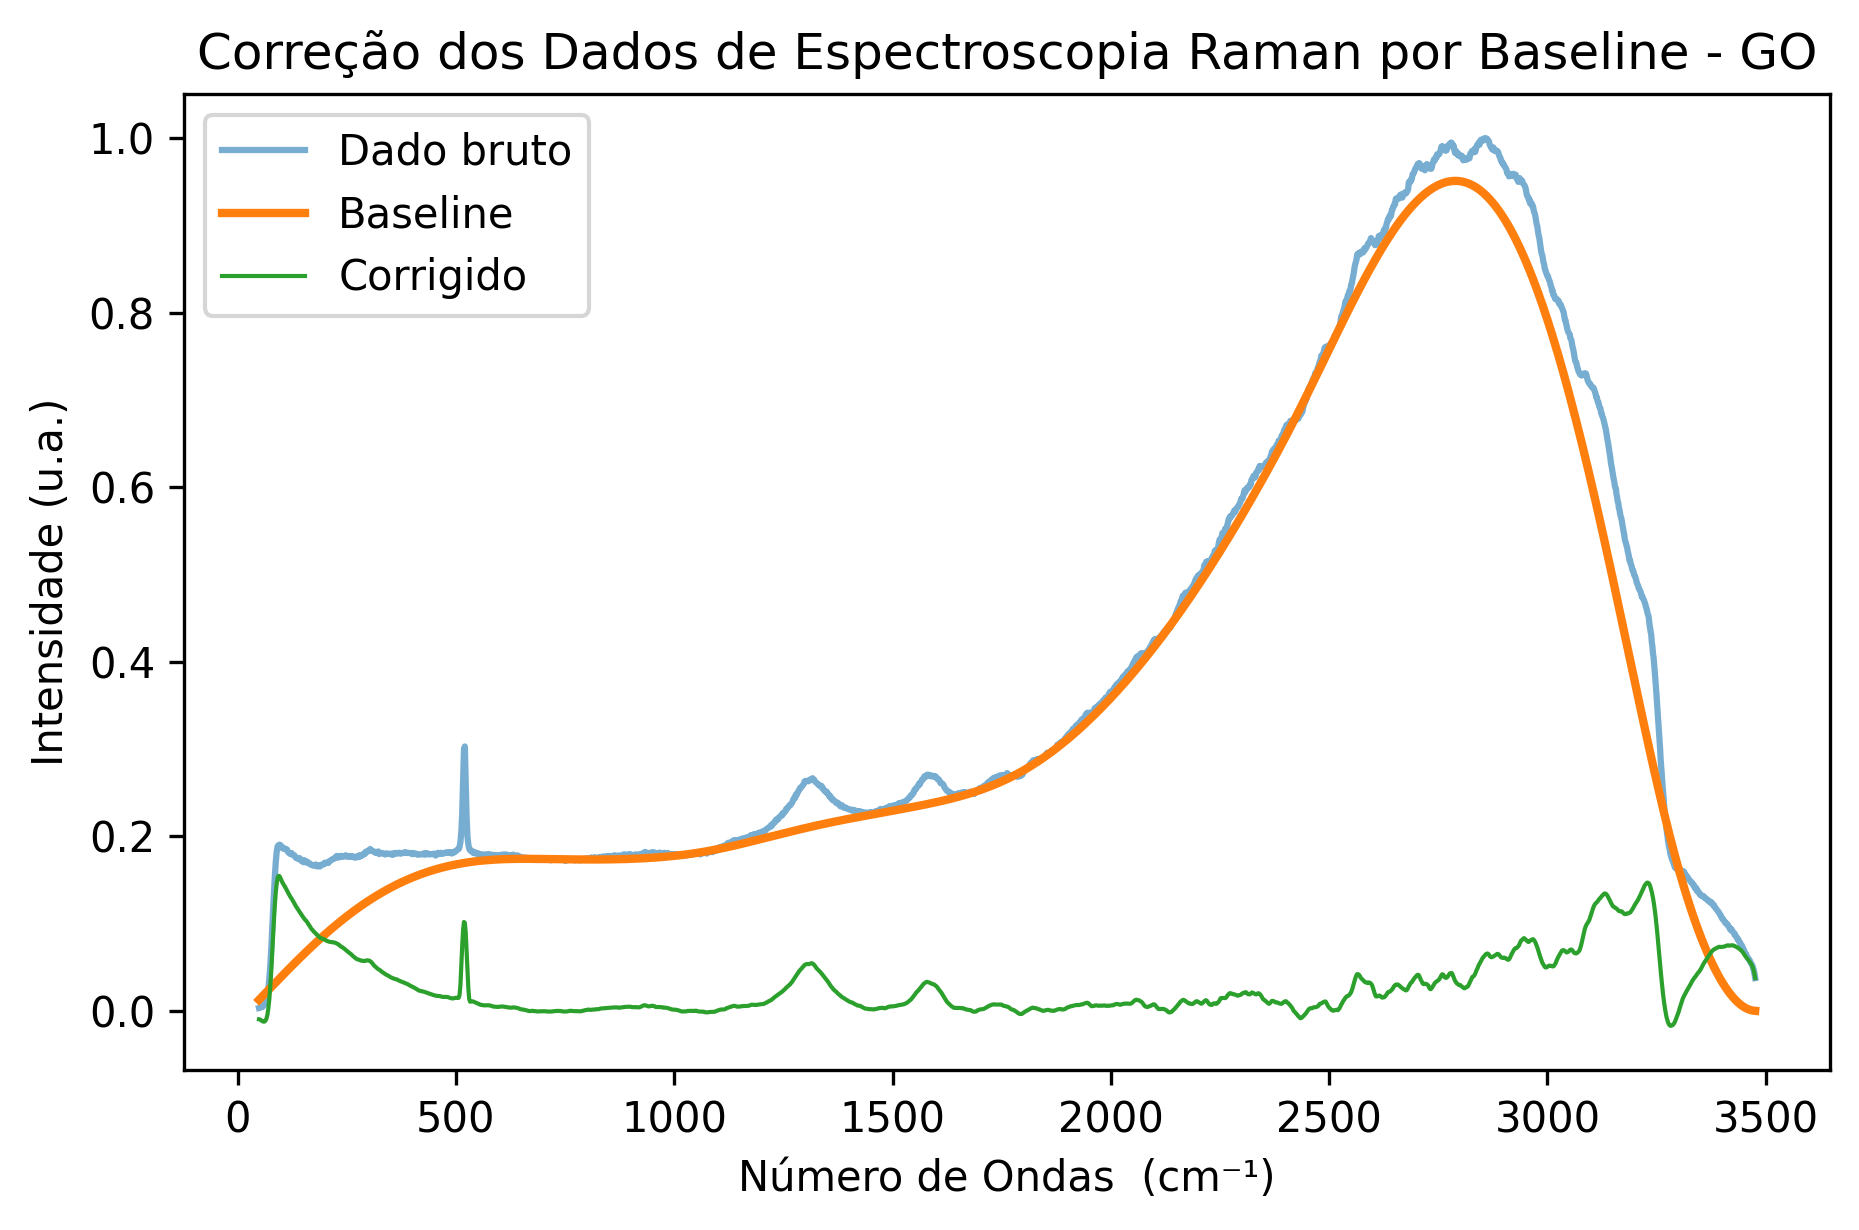

In [247]:
x, y_corr = baseline('rGO_MMV.txt', lam=1e6, p=0.01, n_iter=10)

Área sob o pico D:

In [ ]:
xmin, xmax = 1119.31, 1441.68 # Limites definidos para o pico D
mask = (x >= xmin) & (x <= xmax)
area_D = -trapezoid(y_corr[mask], x[mask])
print(f'Área sob o pico D (rGO): {area_D} (u.a.)')

Área sob o pico D (rGO): 6.750482590103205 (u.a.)


Área sob o pico G:

In [ ]:
xmin, xmax = 1461.37, 1677.89 # Limites definidos para o pico G
mask = (x >= xmin) & (x <= xmax)
area_G = -trapezoid(y_corr[mask], x[mask])
print(f'Área sob o pico G (rGO): {area_G} (u.a.)')

Área sob o pico G (rGO): 2.7039021981503315 (u.a.)


Razão entre as áreas ($\mathrm{\frac{A_D}{A_G}}$):

In [245]:
DG_ratio = area_D / area_G
print(f'Razão D/G (rGO): {DG_ratio}')

Razão D/G (rGO): 2.496570547085998


# Referências

EILERS, P. H. C.; BOELENS, H. F. M. *Baseline correction with asymmetric least squares smoothing*. Leiden University Medical Centre Report, 2005.